In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
%matplotlib inline

In [11]:
train_features = pd.read_csv('../datasets/final_data/train_features_raw.csv')
train_labels = pd.read_csv('../datasets/final_data/train_labels.csv')
train_features.head()

,Pclass,Sex,Age_clean,SibSp,Parch,Fare,Cabin,Embarked
0,-0.408652,0.737125,2.570771,-0.464063,-0.468427,-0.412724,0.450064,0.573494
1,0.803682,0.737125,-1.673694,2.692745,0.794906,-0.066661,0.450064,-0.718682
2,0.803682,0.737125,0.212735,-0.464063,-0.468427,0.441904,0.450064,0.573494
3,0.803682,-1.356623,-0.730480,0.325139,-0.468427,-0.425266,0.450064,0.573494
4,-0.408652,-1.356623,-0.101670,-0.464063,-0.468427,-0.366273,0.450064,0.573494


c:\Users\ThinkPad T460\anaconda3\envs\vi1\lib\site-packages\seaborn\matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


<Axes: >

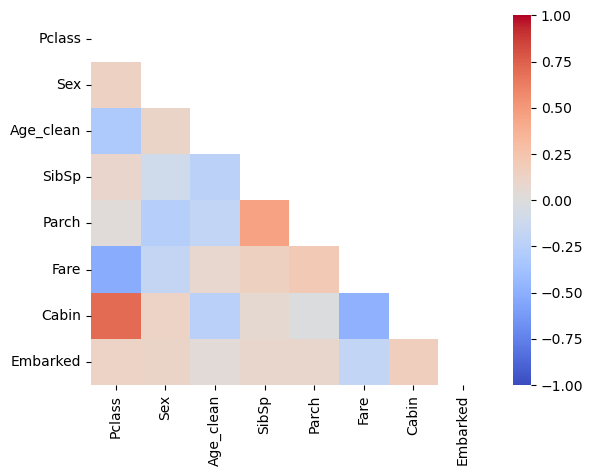

In [12]:
# Generate corellation matrix heat map
matrix = np.triu(train_features.corr())
sns.heatmap(train_features.corr(), annot=True, fmt='1.f', vmin=-1, vmax=1, center=0, cmap='coolwarm', mask=matrix)


In [17]:
# grid search cv
def print_results(results):
    print('BEST PARAMS: {}\n'.format(results.best_params_))
    
    means = results.cv_results_['mean_test_score']
    stds = results.cv_results_['std_test_score']
    for mean, std, params in zip(means, stds, results.cv_results_['params']):
        print('{} (+/-{}) for {}'.format(round(mean, 3), round(std*2,3), params))

In [18]:
rf = RandomForestClassifier()
parameters = {
    'n_estimators':[2**i for i in range(3,10)],
    'max_depth':[2,4,8,16,32,None]
}
cv = GridSearchCV(rf, parameters, cv=5)
cv.fit(train_features, train_labels.values.ravel())

print_results(cv)

BEST PARAMS: {'max_depth': 8, 'n_estimators': 512}

0.787 (+/-0.173) for {'max_depth': 2, 'n_estimators': 8}
0.796 (+/-0.114) for {'max_depth': 2, 'n_estimators': 16}
0.788 (+/-0.093) for {'max_depth': 2, 'n_estimators': 32}
0.802 (+/-0.104) for {'max_depth': 2, 'n_estimators': 64}
0.796 (+/-0.107) for {'max_depth': 2, 'n_estimators': 128}
0.79 (+/-0.106) for {'max_depth': 2, 'n_estimators': 256}
0.792 (+/-0.105) for {'max_depth': 2, 'n_estimators': 512}
0.805 (+/-0.119) for {'max_depth': 4, 'n_estimators': 8}
0.822 (+/-0.086) for {'max_depth': 4, 'n_estimators': 16}
0.824 (+/-0.118) for {'max_depth': 4, 'n_estimators': 32}
0.813 (+/-0.117) for {'max_depth': 4, 'n_estimators': 64}
0.82 (+/-0.11) for {'max_depth': 4, 'n_estimators': 128}
0.822 (+/-0.09) for {'max_depth': 4, 'n_estimators': 256}
0.822 (+/-0.112) for {'max_depth': 4, 'n_estimators': 512}
0.817 (+/-0.075) for {'max_depth': 8, 'n_estimators': 8}
0.837 (+/-0.066) for {'max_depth': 8, 'n_estimators': 16}
0.83 (+/-0.061) for {

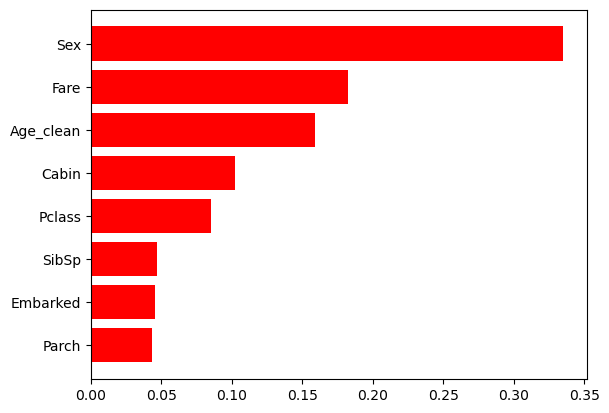

In [21]:
# generate feature importance plot
feat_imp = cv.best_estimator_.feature_importances_
indices = np.argsort(feat_imp)
plt.yticks(range(len(indices)), [train_features.columns[i] for i in indices])
plt.barh(range(len(indicies)), feat_imp[indicies], color='r', align='center')
plt.show()

In [22]:
# write out the model fit on the whole training set
joblib.dump(cv.best_estimator_, './,mdl_raw_original_features.pkl')

['./,mdl_raw_original_features.pkl']